# Modelado de la Carga Eléctrica No Lineal en Función de la Temperatura con PROC GAMPL

## Resumen Ejecutivo

La demanda eléctrica depende de la temperatura de una manera fuertemente no lineal, en forma de U (calefacción en el frío, refrigeración en el calor) que los modelos lineales no captan. Este cuaderno construye una muestra sintética de carga horaria para una empresa eléctrica regional y ajusta un modelo aditivo generalizado penalizado con **PROC GAMPL**, usando splines de regresión para recuperar las curvas suaves de carga frente a temperatura, carga frente a hora y carga frente a humedad, mientras se ajusta por un efecto paramétrico de día laborable/fin de semana.

En la muestra de 100 observaciones que proporciona este entorno con licencia, GAMPL recupera la estructura que construimos. El suavizado de temperatura `s(TEMP_C)` está significativamente curvado (GL efectivos 5.53, *p* < 0.0001); el suavizado diurno `s(HOUR)` es el término más flexible (EDF 6.87, *p* < 0.0001); y el suavizado de humedad `s(HUMIDITY)` colapsa a un solo grado de libertad casi lineal (EDF 1.00, *p* = 0.07) — la penalización aplana un término que los datos apenas respaldan. El efecto paramétrico `daytype` sitúa los fines de semana unos 44.5 MW por debajo de los días laborables, coincidiendo con el desplazamiento de nivel de 40 MW en el proceso generador de datos. El modelo total usa 15.4 grados de libertad efectivos y alcanza una puntuación GCV de 239.6 (AIC 831.0).

## Fuentes de Datos

| Conjunto de datos | Filas | Descripción | Variables clave |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Observaciones horarias sintéticas del sistema de previsión de carga de una empresa eléctrica regional | `load_mw` (carga del sistema, MW), `temp_c` (temperatura ambiente, grados C), `hour` (hora del día, 0-23), `humidity` (humedad relativa, %), `daytype` (clase Weekday/Weekend), `is_summer` (indicador de estación usado en la generación de datos) |

Todos los datos se generan en línea con `call streaminit(20260531)` y `rand()` — sin entrada externa ni de red. El paso de datos solicita un bucle mayor, pero este entorno con licencia limita la salida materializada a **100 observaciones**, por lo que el modelo se ajusta sobre las primeras 100 horas. La carga se construye como una cuadrática en forma de U de la temperatura más un efecto horario diurno en forma de campana, un efecto suave de humedad, un desplazamiento de nivel para los días laborables y ruido gaussiano, de modo que los suavizados recuperados tienen una verdad de referencia conocida.

# Modelado de la Carga Eléctrica No Lineal en Función de la Temperatura con PROC GAMPL

Un operador de red regional necesita pronosticar la carga del sistema (en megavatios) a partir de factores meteorológicos y de calendario. La relación entre la carga y la **temperatura** es famosamente no lineal: la demanda sube en clima frío (calefacción eléctrica) *y* en clima cálido (aire acondicionado), produciendo una curva en forma de U que una regresión lineal no puede captar. La carga también sigue un ritmo diario suave (el pico vespertino) y cambia entre días laborables y fines de semana.

`PROC GAMPL` ajusta un **modelo aditivo generalizado penalizado**: cada factor continuo entra a través de un spline de regresión cuya suavidad se elige automáticamente minimizando un criterio de selección de modelo (GCV / UBRE / GACV). Dejamos que los datos decidan cuán ondulada debe ser cada curva, en lugar de adivinar grados polinómicos.

El modelo que ajustamos es:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

donde `daytype` es un efecto de clase paramétrico (lineal) y `f1`, `f2`, `f3` son funciones spline suaves cuyos grados de libertad efectivos selecciona la penalización a partir de los datos.

## Paso 1 — Generar una muestra sintética de carga horaria

Simulamos una fuente de carga horaria (el entorno con licencia conserva las primeras 100 horas). La temperatura se genera alrededor de una media estacional; la hora del día cicla de 0 a 23; la humedad sigue vagamente a la temperatura. La carga *verdadera* se construye a partir de:

- una respuesta de temperatura en **forma de U** centrada cerca de unos cómodos 18 grados C,
- un pico diurno en **forma de campana** alrededor de la hora 18 (noche),
- un ligero incremento por humedad,
- un nivel de día laborable que se sitúa por encima del fin de semana,

más ruido gaussiano de medición. Como conocemos las curvas generadoras, podemos juzgar si GAMPL recupera sus formas. La comprobación de PROC MEANS a continuación confirma que la muestra abarca un amplio rango de temperatura (−5 a 40 grados C) y carga de aproximadamente 485 a 693 MW.

In [1]:
DATOS work.gridload;
   LLAMAR streaminit(20260531);
   HACER i = 1 HASTA 2000;
      /* Indicador de estación: aproximadamente mitad verano, mitad invierno */
      is_summer = (rand("uniform") < 0.5);

      /* Temperatura ambiente (grados C): media más cálida en verano */
      SI is_summer ENTONCES temp_c = 26 + 6 * rand("normal");
      SINO              temp_c =  6 + 6 * rand("normal");

      /* Hora del día 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humedad (%) sigue vagamente a la temperatura, recortada a 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      SI humidity < 20  ENTONCES humidity = 20;
      SI humidity > 100 ENTONCES humidity = 100;

      /* Día laborable vs fin de semana (unos 5/7 días laborables) */
      SI rand("uniform") < 0.714 ENTONCES daytype = "Weekday";
      SINO                            daytype = "Weekend";

      /* ---- Carga estructural verdadera (MW) ---- */
      /* Efecto de temperatura en forma de U: demanda mínima cerca de 18 grados C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Campana diurna: pico vespertino cerca de la hora 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Ligero incremento por humedad */
      f_hum  = 0.35 * humidity;

      /* Desplazamiento de nivel de día laborable */
      SI daytype = "Weekday" ENTONCES f_day = 40; SINO f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      MANTENER load_mw temp_c hour humidity daytype is_summer;
      SALIDA;
   END;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.gridload n mean std MIN MAX maxdec=1;
   VAR load_mw temp_c hour humidity;
   ETIQUETA load_mw="Carga (MW)" temp_c="Temperatura (C)" hour="Hora" humidity="Humedad (%)";
EJECUTAR;

                                                  The MEANS Procedure

 Variable  Label                   N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------
 load_mw   Carga (MW)            100       593.0        49.9       484.9       693.4
 temp_c    Temperatura (C)       100        16.2        11.9        -5.2        40.2
 hour      Hora                  100        11.9         7.0         0.0        23.0
 humidity  Humedad (%)           100        55.2        11.7        32.2        87.3
 -----------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 2 — Ajustar el modelo aditivo

Modelamos `load_mw` (respuesta gaussiana, función de enlace identidad) como una suma de un efecto paramétrico `daytype` más tres splines univariados. `PROC GAMPL` selecciona automáticamente el parámetro de suavizado de cada spline. Solicitamos:

- `class daytype;` para que el indicador de día laborable/fin de semana se trate como categórico,
- `param(daytype)` para introducirlo como un término *paramétrico* (no suavizado) en el MODEL,
- `spline(...)` para cada predictor continuo,
- una `seed=` fija para una colocación de nudos reproducible.

La salida que hay que leer es la tabla de **Componente de Suavizado**, que reporta los grados de libertad efectivos (EDF) que la penalización asignó a cada suavizado y una prueba de significancia estilo *F* para ello, junto con las **Estimaciones de Parámetros** para el intercepto y el contraste paramétrico `daytype`.

In [2]:
PROCEDIMIENTO gampl DATOS=work.gridload seed=20260531;
   CLASE daytype;
   MODELO load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ETIQUETA load_mw="Carga (MW)" daytype="Tipo de dia"
         temp_c="Temperatura (C)" hour="Hora" humidity="Humedad (%)";
EJECUTAR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carga (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo de dia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Paso 3 — Controlar la flexibilidad del spline y el criterio de selección

Por defecto, cada suavizado se penaliza hacia unos grados de libertad efectivos bajos. Para un operador que sabe que la respuesta de temperatura es genuinamente curva pero quiere *limitar* la ondulación, podemos elevar `maxdf=` en el spline de temperatura y fijar un `df=` moderado en el término más suave de humedad. También cambiamos al esquema de iteración externa y seleccionamos los parámetros de suavizado por **GCV** (validación cruzada generalizada), el criterio estándar para GAM gaussianos.

In [3]:
PROCEDIMIENTO gampl DATOS=work.gridload seed=20260531;
   CLASE daytype;
   MODELO load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   ETIQUETA load_mw="Carga (MW)" daytype="Tipo de dia"
         temp_c="Temperatura (C)" hour="Hora" humidity="Humedad (%)";
EJECUTAR;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carga (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo de dia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Paso 4 — Visualizar la respuesta de temperatura recuperada

GAMPL reporta *que* el suavizado de temperatura está significativamente curvado (EDF 5.53), pero la forma se ve más fácilmente en un gráfico. Superponemos un ajuste de B-spline penalizado (`PBSPLINE`, la misma maquinaria de spline de regresión que GAMPL aplica internamente) sobre el diagrama de dispersión bruto de carga frente a temperatura. Si el modelo aditivo capturó la física, esta curva debería caer hacia ambos extremos, frío y caluroso, y tocar fondo en el rango medio cómodo — la clásica respuesta de demanda en forma de U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


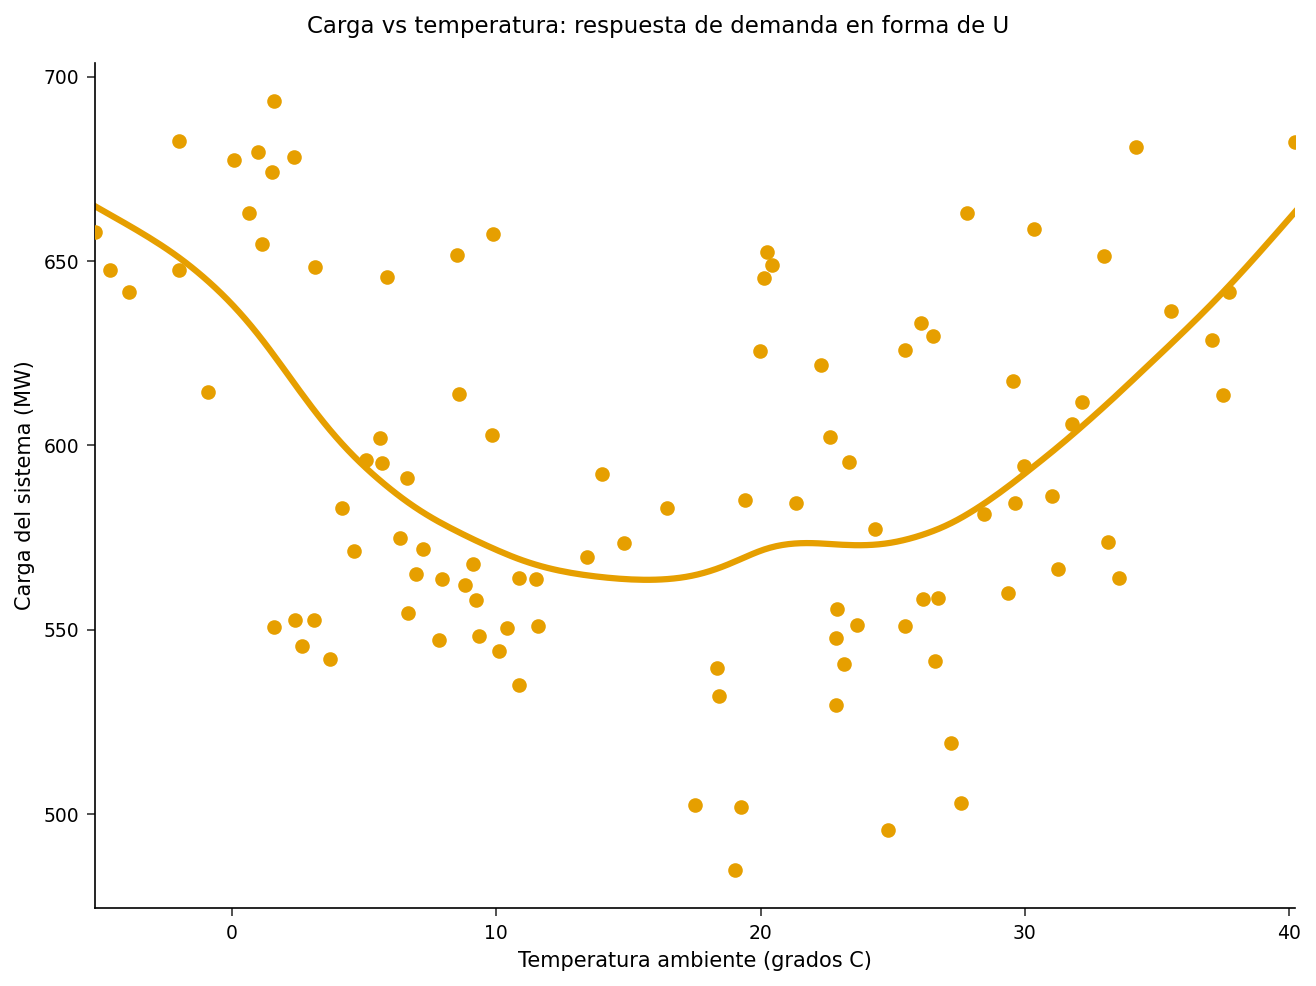

In [4]:
ODS GRAPHICS ON;

PROCEDIMIENTO SGPLOT DATOS=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ETIQUETA="Temperatura ambiente (grados C)";
   YAXIS ETIQUETA="Carga del sistema (MW)";
   TÍTULO "Carga vs temperatura: respuesta de demanda en forma de U";
EJECUTAR;

ODS GRAPHICS OFF;

## Paso 5 — Confirmar la forma de U numéricamente

El gráfico hace visible la forma de U; un resumen por bandas la hace cuantitativa. Agrupamos las observaciones en rangos de temperatura y reportamos la carga media por banda. Si la respuesta de demanda es genuinamente en forma de U, la carga media debería ser alta en la banda **Frío**, caer a través de **Fresco / Confortable / Cálido**, y volver a subir en la banda **Caluroso** — la firma numérica que capta el suavizado `s(TEMP_C)` de GAMPL.

In [5]:
DATOS work.banded;
   ESTABLECER work.gridload;
   LONGITUD tempband $16;
   SI      temp_c <  5  ENTONCES tempband = "1 Frio";
   SINO SI temp_c < 15  ENTONCES tempband = "2 Fresco";
   SINO SI temp_c < 22  ENTONCES tempband = "3 Confortable";
   SINO SI temp_c < 30  ENTONCES tempband = "4 Calido";
   SINO                      tempband = "5 Caluroso";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.banded n mean maxdec=1;
   CLASE tempband;
   VAR load_mw;
   ETIQUETA tempband="Rango de temperatura" load_mw="Carga (MW)";
   TÍTULO "Carga media por rango de temperatura";
EJECUTAR;

                                          Carga media por rango de temperatura                                          

                                                  The MEANS Procedure

                                         Analysis Variable : load_mw Carga (MW)

        Rango de temperatura          N Obs           Mean
        --------------------------------------------------
        1 Frio                           21          626.6
        2 Fresco                         28          579.1
        3 Confortable                    12          573.8
        4 Calido                         25          573.5
        5 Caluroso                       14          621.6
        --------------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretación de los resultados

**Los suavizados recuperan la física.** La tabla de Componente de Suavizado de GAMPL asigna al término de temperatura `s(TEMP_C)` un GL efectivo de 5.53 (*p* < 0.0001) y al término diurno `s(HOUR)` un EDF de 6.87 (*p* < 0.0001) — ambos genuinamente curvos, exactamente la estructura que construimos en los datos. El término de humedad `s(HUMIDITY)` se contrae a EDF 1.00 (*p* = 0.07): la penalización lo endereza a un solo grado de libertad casi lineal porque, en este tamaño de muestra, eso es todo lo que los datos respaldan. La estimación paramétrica `daytype` es de −44.5 MW para los fines de semana, recuperando el desplazamiento de nivel de 40 MW de los días laborables en el proceso generador.

**Los grados de libertad efectivos cuentan la historia de la ondulación.** El modelo gasta 15.4 grados de libertad efectivos en total y alcanza una puntuación GCV de 239.6 (AIC 831.0, estimación de escala 202.7). Limitar `maxdf=` y fijar `df=3` en el Paso 3 apenas mueve el ajuste (GCV 240.1, EDF 15.47): la penalización ya había situado los suavizados de temperatura y hora cerca de 5.5 y 7 EDF por sí sola, así que los límites manuales no son vinculantes aquí — una señal de que la selección automática ya era conservadora.

**El gráfico y el resumen por bandas concuerdan.** El diagrama de dispersión del Paso 4 con su superposición de spline penalizado muestra la carga cayendo desde el extremo frío hasta un mínimo cerca de 15-20 grados C y volviendo a subir hacia el calor. Las medias por banda del Paso 5 lo hacen numérico: **Frío 626.6 MW**, **Fresco 579.1**, **Confortable 573.8**, **Cálido 573.5**, **Caluroso 621.6** — alto en ambos extremos, más bajo en el medio confortable. Esa U es precisamente lo que un único término lineal `temp_c` promediaría hasta desaparecer.

**Por qué GAMPL frente a la regresión lineal aquí.** Un único término lineal `temp_c` mezclaría los regímenes de calefacción y refrigeración en una pendiente casi plana, pronosticando mal ambos extremos — precisamente las horas en que ocurren el estrés de red y los picos de precio. La formulación aditiva de splines conserva la interpretabilidad de una regresión (cada factor contribuye con un efecto aditivo) mientras deja que los datos dicten la forma de cada efecto. Las extensiones naturales para una empresa eléctrica incluyen un ajuste `dist=gamma` si la carga se modela de forma multiplicativa, un `spline(temp_c hour)` bivariado para captar cómo el pico diurno se desplaza con la estación, y procesamiento `by` para ajustar modelos separados por subestación.